In [49]:
import pandas as pd
import numpy as np
import warnings
import os
import seaborn as sns
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, precision_score, recall_score
)
from sklearn.model_selection import TimeSeriesSplit

# ── reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style
FIG_COLOR  = "#0D0D14"
ACCENT1    = "#00E5CC"
ACCENT2    = "#FF6B6B"
ACCENT3    = "#FFD166"
ACCENT4    = "#A78BFA"
GRID_COLOR = "#1E1E2E"


# 0: LOAD SPLITS

In [50]:
BASE = "../../../data/processed/splits/"

X_train = pd.read_csv(BASE + "X_train.csv", parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv(BASE + "X_val.csv",   parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv(BASE + "X_test.csv",  parse_dates=["Date"], index_col="Date")

y_reg_train = pd.read_csv(BASE + "y_train_reg.csv", parse_dates=["Date"], index_col="Date").squeeze()
y_reg_val   = pd.read_csv(BASE + "y_val_reg.csv",   parse_dates=["Date"], index_col="Date").squeeze()
y_reg_test  = pd.read_csv(BASE + "y_test_reg.csv",  parse_dates=["Date"], index_col="Date").squeeze()

X_trainval     = pd.concat([X_train, X_val])
y_reg_trainval = pd.concat([y_reg_train, y_reg_val])

print(f"  X_train    : {X_train.shape}")
print(f"  X_val      : {X_val.shape}")
print(f"  X_test     : {X_test.shape}")


  X_train    : (1479, 69)
  X_val      : (501, 69)
  X_test     : (563, 69)


In [51]:
# Binary labels (Up=1, Down=0)
y_bin_train    = (y_reg_train > 0).astype(int)
y_bin_val      = (y_reg_val > 0).astype(int)
y_bin_test     = (y_reg_test > 0).astype(int)
y_bin_trainval = (y_reg_trainval > 0).astype(int)


In [52]:
#  HELPER METRICS
def evaluate_clf(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred) * 100
    f1   = f1_score(y_true, y_pred, average="macro") * 100
    prec = precision_score(y_true, y_pred, zero_division=0) * 100
    rec  = recall_score(y_true, y_pred, zero_division=0) * 100
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else float("nan")
    print(f"  [{name}] Acc={acc:.1f}%  F1={f1:.1f}%  Prec={prec:.1f}%  Rec={rec:.1f}%  AUC={auc:.4f}")
    return {"acc": acc, "f1": f1, "prec": prec, "rec": rec, "auc": auc}


# STEP 1: USE ALL FEATURE 

In [53]:
X_tr = X_train.copy()
X_vl = X_val.copy()
X_te = X_test.copy()
X_tv = X_trainval.copy()

print(f"  Original features: {X_train.shape[1]}")
print(f"  Selected features: {X_tr.shape[1]}")


  Original features: 69
  Selected features: 69


# STEP 2: CLASS IMBALANCE CHECK

In [54]:
n_up   = y_bin_train.sum()
n_down = (y_bin_train == 0).sum()
spw    = n_down / n_up if n_up > 0 else 1.0
print(f"  Up={n_up} Down={n_down}  scale_pos_weight={spw:.4f}")


  Up=760 Down=719  scale_pos_weight=0.9461


# STEP 3: HYPERPARAMETER TUNING (OPTUNA)

In [55]:
N_SPLITS = 5
N_TRIALS = 50
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=1)


In [56]:
def lgb_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 16, 96),
        "max_depth"        : trial.suggest_int("max_depth", 3, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 100),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight" : spw,
        "objective"        : "binary",
        "metric"           : "auc",
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
        "verbose"          : -1,
    }
    scores = []
    for tr_idx, vl_idx in tscv.split(X_tv):
        Xtr = X_tv.iloc[tr_idx]; Xvl = X_tv.iloc[vl_idx]
        ytr = y_bin_trainval.iloc[tr_idx]; yvl = y_bin_trainval.iloc[vl_idx]
        
        m = lgb.LGBMClassifier(**params)
        m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
        scores.append(roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1]))
    return -np.mean(scores)


In [57]:
def xgb_objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 7),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma"           : trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight": spw,
        "objective"       : "binary:logistic",
        "eval_metric"     : "auc",
        "random_state"    : RANDOM_STATE,
        "n_jobs"          : -1,
        "tree_method"     : "hist",
        "verbosity"       : 0,
    }
    scores = []
    for tr_idx, vl_idx in tscv.split(X_tv):
        Xtr = X_tv.iloc[tr_idx]; Xvl = X_tv.iloc[vl_idx]
        ytr = y_bin_trainval.iloc[tr_idx]; yvl = y_bin_trainval.iloc[vl_idx]
        
        m = xgb.XGBClassifier(**params)
        m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)], verbose=False)
        scores.append(roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1]))
    return -np.mean(scores)


In [58]:
print(f"\n  [Optuna] LightGBM — {N_TRIALS} trials ...")
study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_lgb = study_lgb.best_params.copy()
best_lgb.update({"objective": "binary", "metric": "auc", "scale_pos_weight": spw,
                 "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
print(f"  LightGBM best CV AUC : {-study_lgb.best_value:.4f}")



  [Optuna] LightGBM — 50 trials ...
  LightGBM best CV AUC : 0.5465


In [59]:
print(f"\n  [Optuna] XGBoost — {N_TRIALS} trials ...")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_xgb = study_xgb.best_params.copy()
best_xgb.update({"objective": "binary:logistic", "eval_metric": "auc", "scale_pos_weight": spw,
                 "random_state": RANDOM_STATE, "n_jobs": -1, "tree_method": "hist", "verbosity": 0})
print(f"  XGBoost best CV AUC  : {-study_xgb.best_value:.4f}")



  [Optuna] XGBoost — 50 trials ...
  XGBoost best CV AUC  : 0.5308


# STEP 4: TRAIN BASE MODELS

In [60]:
lgb_m = lgb.LGBMClassifier(**best_lgb)
lgb_m.fit(X_tr, y_bin_train, eval_set=[(X_vl, y_bin_val)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

,boosting_type,'gbdt'
,num_leaves,55
,max_depth,5
,learning_rate,0.023156834553476297
,n_estimators,779
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,23


In [61]:
xgb_m = xgb.XGBClassifier(**best_xgb)
xgb_m.fit(X_tr, y_bin_train, eval_set=[(X_vl, y_bin_val)], verbose=False)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7856138762805643
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

In [62]:
cat_m = CatBoostClassifier(
    iterations=1000, learning_rate=0.03, depth=6,
    l2_leaf_reg=3.0, min_data_in_leaf=20,
    bootstrap_type="Bernoulli", subsample=0.8,
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE, verbose=0,
    early_stopping_rounds=50, eval_metric="AUC", task_type="CPU"
)
cat_m.fit(X_tr, y_bin_train, eval_set=(X_vl, y_bin_val), verbose=False)

CatBoostClassifier(auto_class_weights='Balanced', bootstrap_type='Bernoulli', depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, l2_leaf_reg=3.0, learning_rate=0.03, min_data_in_leaf=20, random_seed=42, subsample=0.8, task_type='CPU', verbose=0)

In [63]:
# Val predictions (Uncalibrated)
prob_val_lgb = lgb_m.predict_proba(X_vl)[:, 1]
prob_val_xgb = xgb_m.predict_proba(X_vl)[:, 1]
prob_val_cat = cat_m.predict_proba(X_vl)[:, 1]
prob_val_ens = (prob_val_lgb + prob_val_xgb + prob_val_cat) / 3.0


In [64]:
# Test predictions (Uncalibrated)
prob_test_lgb = lgb_m.predict_proba(X_te)[:, 1]
prob_test_xgb = xgb_m.predict_proba(X_te)[:, 1]
prob_test_cat = cat_m.predict_proba(X_te)[:, 1]
prob_test_ens = (prob_test_lgb + prob_test_xgb + prob_test_cat) / 3.0


In [65]:
print("\n  --- Ensemble Performance (Default threshold 0.50) ---")
m_ens_val  = evaluate_clf("ENS val", y_bin_val, (prob_val_ens >= 0.5).astype(int), prob_val_ens)
m_ens_test = evaluate_clf("ENS test", y_bin_test, (prob_test_ens >= 0.5).astype(int), prob_test_ens)



  --- Ensemble Performance (Default threshold 0.50) ---
  [ENS val] Acc=51.7%  F1=51.7%  Prec=51.6%  Rec=51.6%  AUC=0.5336
  [ENS test] Acc=51.9%  F1=51.6%  Prec=55.7%  Rec=54.8%  AUC=0.5302


# STEP 5: THRESHOLD TUNING 

In [66]:
thresholds = np.arange(0.30, 0.71, 0.01)
thresh_results = []
for t in thresholds:
    pred_t = (prob_val_ens >= t).astype(int)
    acc_t  = accuracy_score(y_bin_val, pred_t) * 100
    thresh_results.append({"threshold": round(t, 2), "acc": acc_t})


In [67]:
thresh_df = pd.DataFrame(thresh_results)
best_thresh = thresh_df.loc[thresh_df["acc"].idxmax(), "threshold"]
best_thresh_acc = thresh_df["acc"].max()


In [68]:
print(f"\n  Default threshold (0.50) Val Acc: {accuracy_score(y_bin_val, (prob_val_ens >= 0.50).astype(int))*100:.1f}%")
print(f"  Optimal threshold ({best_thresh:.2f}) Val Acc: {best_thresh_acc:.1f}%")



  Default threshold (0.50) Val Acc: 51.7%
  Optimal threshold (0.51) Val Acc: 52.7%


In [69]:
# Apply on Test
pred_test_tuned = (prob_test_ens >= best_thresh).astype(int)
acc_test_tuned  = accuracy_score(y_bin_test, pred_test_tuned) * 100

print(f"\n  --- Test Performance (Tuned thresh={best_thresh:.2f}) ---")
m_tuned_test = evaluate_clf("ENS tuned", y_bin_test, pred_test_tuned, prob_test_ens)



  --- Test Performance (Tuned thresh=0.51) ---
  [ENS tuned] Acc=50.4%  F1=49.3%  Prec=57.6%  Rec=32.5%  AUC=0.5302


# STEP 6: WALK-FORWARD VALIDATION

In [70]:
WF_INIT = len(X_tr)
WF_STEP = 63
X_wf    = pd.concat([X_tr, X_vl, X_te])
y_wf    = pd.concat([y_bin_train, y_bin_val, y_bin_test])

wf_preds, wf_probs, wf_acts, wf_dates, wf_metrics = [], [], [], [], []
start = WF_INIT; n_total = len(X_wf); fold = 0


In [71]:
while start < n_total:
    end = min(start + WF_STEP, n_total)
    
    Xf_tr = X_wf.iloc[:start]; Xf_te = X_wf.iloc[start:end]
    yf_tr = y_wf.iloc[:start]; yf_te = y_wf.iloc[start:end]

    wf_lgb = lgb.LGBMClassifier(**best_lgb)
    wf_lgb.fit(Xf_tr, yf_tr, callbacks=[lgb.log_evaluation(-1)])

    raw_prob  = wf_lgb.predict_proba(Xf_te)[:, 1]
    pred_fold = (raw_prob >= best_thresh).astype(int)
    
    acc_fold = accuracy_score(yf_te, pred_fold) * 100
    auc_fold = roc_auc_score(yf_te, raw_prob) if len(np.unique(yf_te)) > 1 else 0.5
    
    wf_preds.extend(pred_fold.tolist())
    wf_probs.extend(raw_prob.tolist())
    wf_acts.extend(yf_te.tolist())
    wf_dates.extend(yf_te.index.tolist())
    
    wf_metrics.append({
        "fold": fold, "start": yf_te.index[0].date(), "end": yf_te.index[-1].date(),
        "n_rows": len(yf_te), "Acc%": acc_fold, "AUC": round(auc_fold, 4),
    })
    
    fold += 1; start = end


In [72]:
wf_df = pd.DataFrame({"actual": wf_acts, "pred": wf_preds, "prob": wf_probs}, index=wf_dates)
wf_acc = accuracy_score(wf_df["actual"], wf_df["pred"]) * 100
wf_auc = roc_auc_score(wf_df["actual"], wf_df["prob"])


In [73]:
print("\n  Walk-Forward fold results:")
print(pd.DataFrame(wf_metrics).to_string(index=False))
print(f"\n  Overall Acc = {wf_acc:.1f}%")
print(f"  Overall AUC = {wf_auc:.4f}")



  Walk-Forward fold results:
 fold      start        end  n_rows      Acc%    AUC
    0 2022-01-03 2022-04-01      63 50.793651 0.5154
    1 2022-04-04 2022-07-05      63 46.031746 0.5243
    2 2022-07-06 2022-10-03      63 53.968254 0.5131
    3 2022-10-04 2023-01-03      63 53.968254 0.4647
    4 2023-01-04 2023-04-04      63 44.444444 0.4384
    5 2023-04-05 2023-07-06      63 52.380952 0.5847
    6 2023-07-07 2023-10-04      63 44.444444 0.4208
    7 2023-10-05 2024-01-04      63 42.857143 0.4541
    8 2024-01-05 2024-04-05      63 42.857143 0.4220
    9 2024-04-08 2024-07-08      63 63.492063 0.5639
   10 2024-07-09 2024-10-04      63 58.730159 0.6310
   11 2024-10-07 2025-01-06      63 50.793651 0.4650
   12 2025-01-07 2025-04-07      63 42.857143 0.4348
   13 2025-04-08 2025-07-08      63 46.031746 0.5114
   14 2025-07-09 2025-10-06      63 36.507937 0.3793
   15 2025-10-07 2026-01-06      63 55.555556 0.5444
   16 2026-01-07 2026-03-27      56 55.357143 0.4466

  Overall Acc =

# STEP 7: SIGNAL FUSION (Percentile-Based Buy / Hold / Sell)

In [74]:
conf_results = []
for q in np.arange(55, 95, 5): 
    theta_h = np.percentile(prob_val_ens, q)
    theta_l = np.percentile(prob_val_ens, 100 - q)
    
    sig_val = np.where(prob_val_ens >= theta_h, "Buy",
              np.where(prob_val_ens <= theta_l, "Sell", "Hold"))
    
    mask_active = sig_val != "Hold"
    if mask_active.sum() < 20: 
        continue
        
    actual_dir = np.where(y_bin_val.values[mask_active] == 1, "Buy", "Sell")
    pred_dir   = sig_val[mask_active]
    active_acc = (actual_dir == pred_dir).mean() * 100
    coverage   = mask_active.mean() * 100
    
    conf_results.append({
        "percentile": int(q),
        "theta_h"   : round(theta_h, 4),
        "theta_l"   : round(theta_l, 4),
        "active_acc": active_acc,
        "coverage%" : coverage,
        "n_active"  : int(mask_active.sum()),
    })

conf_df = pd.DataFrame(conf_results)

In [75]:
if len(conf_df) > 0:
    eligible = conf_df[conf_df["coverage%"] >= 15.0]
    if len(eligible) > 0:
        best_conf = eligible.loc[eligible["active_acc"].idxmax()]
    else:
        best_conf = conf_df.loc[conf_df["active_acc"].idxmax()]
    
    THETA_H = best_conf["theta_h"]
    THETA_L = best_conf["theta_l"]
    BEST_Q  = best_conf["percentile"]
else:
    THETA_H = np.percentile(prob_val_ens, 75)
    THETA_L = np.percentile(prob_val_ens, 25)
    BEST_Q  = 75


In [76]:
print(f"\n  Best Percentile: Top {100-BEST_Q}% / Bottom {100-BEST_Q}%")
print(f"  Mapped Thresholds: θ_high={THETA_H:.4f}  θ_low={THETA_L:.4f}")



  Best Percentile: Top 15.0% / Bottom 15.0%
  Mapped Thresholds: θ_high=0.5204  θ_low=0.4803


In [77]:
sig_test = np.where(prob_test_ens >= THETA_H, "Buy",
           np.where(prob_test_ens <= THETA_L, "Sell", "Hold"))
sig_series = pd.Series(sig_test, index=X_te.index, name="signal")


In [78]:
mask_active_test = sig_series != "Hold"
actual_dir_test  = np.where(y_bin_test.values == 1, "Buy", "Sell")
active_acc_test  = (actual_dir_test[mask_active_test] == sig_test[mask_active_test]).mean() * 100 if mask_active_test.sum() > 0 else 0


In [79]:
print(f"\n  Test signal distribution:")
for sig, cnt in sig_series.value_counts().items():
    print(f"    {sig:4s}: {cnt:4d} ({(cnt/len(sig_series)*100):.1f}%)")



  Test signal distribution:
    Hold:  423 (75.1%)
    Buy :   78 (13.9%)
    Sell:   62 (11.0%)


In [80]:
print(f"\n  Test active accuracy : {active_acc_test:.1f}%")
print(f"  Test coverage        : {(mask_active_test.mean()*100):.1f}%")



  Test active accuracy : 53.6%
  Test coverage        : 24.9%


In [81]:
output_df = pd.DataFrame({
    "y_actual"      : y_bin_test.values,
    "prob_up"       : prob_test_ens,
    "pred_direction": np.where(prob_test_ens >= best_thresh, "Up", "Down"),
    "signal"        : sig_series.values,
}, index=X_te.index)


In [82]:
output_df["signal_correct"] = np.where(
    output_df["signal"] == "Hold", np.nan,
    (actual_dir_test == sig_test).astype(float)
)

In [83]:
print(f"\n  Sample output (first 10):")
print(output_df.head(10).to_string())



  Sample output (first 10):
            y_actual   prob_up pred_direction signal  signal_correct
Date                                                                
2024-01-02         0  0.479181           Down   Sell             1.0
2024-01-03         1  0.497067           Down   Hold             NaN
2024-01-04         1  0.508016           Down   Hold             NaN
2024-01-05         0  0.505838           Down   Hold             NaN
2024-01-08         0  0.524484             Up    Buy             0.0
2024-01-09         0  0.511490             Up   Hold             NaN
2024-01-10         0  0.511950             Up   Hold             NaN
2024-01-11         1  0.561627             Up    Buy             1.0
2024-01-12         0  0.481998           Down   Hold             NaN
2024-01-16         0  0.502422           Down   Hold             NaN


# STEP 8: VISUALIZATION

#### P1: Optuna History

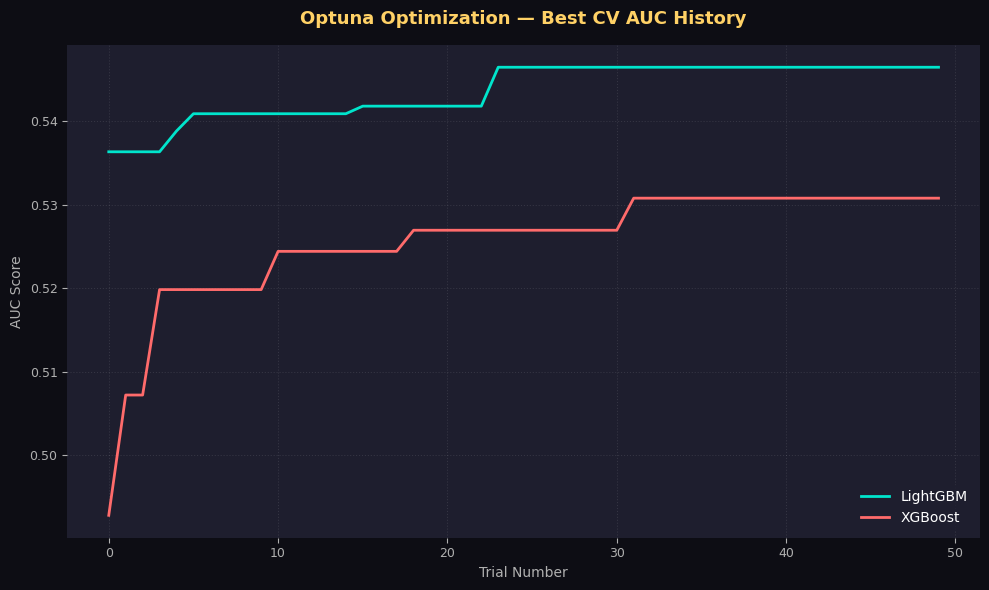

In [84]:
fig = plt.figure(figsize=(10, 6), facecolor=FIG_COLOR)
ax1 = fig.add_subplot(111)
ax1.set_facecolor(GRID_COLOR)

lgb_vals = [-t.value for t in study_lgb.trials]
xgb_vals = [-t.value for t in study_xgb.trials]

ax1.plot(np.maximum.accumulate(lgb_vals), color=ACCENT1, lw=2, label="LightGBM")
ax1.plot(np.maximum.accumulate(xgb_vals), color=ACCENT2, lw=2, label="XGBoost")

ax1.set_title("Optuna Optimization — Best CV AUC History", color=ACCENT3, fontsize=13, fontweight="bold", pad=15)
ax1.set_xlabel("Trial Number", color="#b0b0b0", fontsize=10)
ax1.set_ylabel("AUC Score", color="#b0b0b0", fontsize=10)

ax1.legend(fontsize=10, facecolor=GRID_COLOR, labelcolor="white", edgecolor="none", loc="lower right")
ax1.tick_params(colors="#b0b0b0", labelsize=9)

for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.yaxis.grid(True, linestyle=":", alpha=0.1, color="white")
ax1.xaxis.grid(True, linestyle=":", alpha=0.1, color="white")

plt.tight_layout()
plt.show()

#### P2: Uncalibrated Prob Distribution

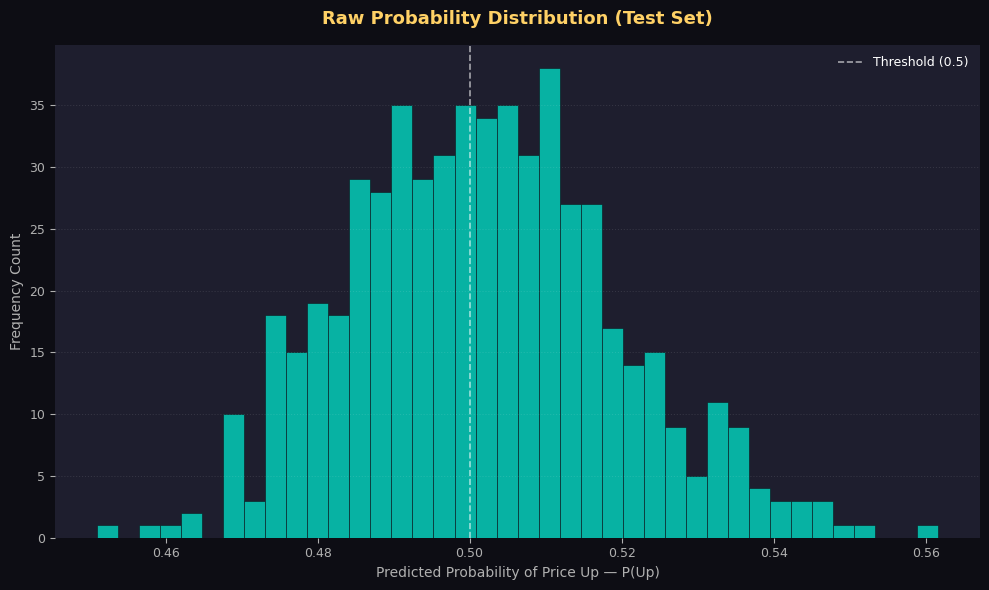

In [85]:
fig = plt.figure(figsize=(10, 6), facecolor=FIG_COLOR)
ax2 = fig.add_subplot(111)
ax2.set_facecolor(GRID_COLOR)

ax2.hist(prob_test_ens, bins=40, color=ACCENT1, alpha=0.75, edgecolor=FIG_COLOR, lw=0.5)
ax2.axvline(0.5, color="white", lw=1.2, linestyle="--", alpha=0.6, label="Threshold (0.5)")

ax2.set_title("Raw Probability Distribution (Test Set)", color=ACCENT3, fontsize=13, fontweight="bold", pad=15)
ax2.set_xlabel("Predicted Probability of Price Up — P(Up)", color="#b0b0b0", fontsize=10)
ax2.set_ylabel("Frequency Count", color="#b0b0b0", fontsize=10)

ax2.legend(fontsize=9, facecolor=GRID_COLOR, labelcolor="white", edgecolor="none")
ax2.tick_params(colors="#b0b0b0", labelsize=9)

for spine in ax2.spines.values():
    spine.set_visible(False)

ax2.yaxis.grid(True, linestyle=":", alpha=0.1, color="white")

plt.tight_layout()
plt.show()

#### P3: Threshold sweep

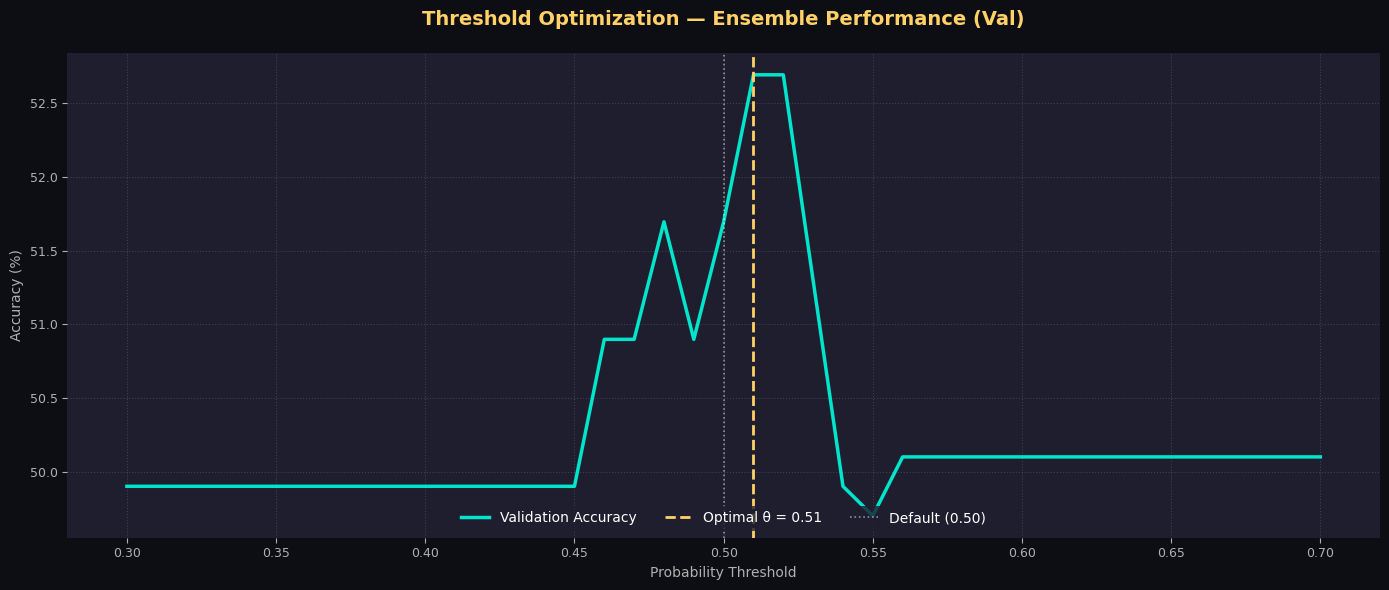

In [86]:
fig = plt.figure(figsize=(14, 6), facecolor=FIG_COLOR)
ax3 = fig.add_subplot(111)
ax3.set_facecolor(GRID_COLOR)

ax3.plot(thresh_df["threshold"], thresh_df["acc"], color=ACCENT1, lw=2.5, label="Validation Accuracy")
ax3.axvline(best_thresh, color=ACCENT3, lw=2, linestyle="--", label=f"Optimal θ = {best_thresh:.2f}")
ax3.axvline(0.50, color="white", lw=1.2, linestyle=":", alpha=0.5, label="Default (0.50)")

ax3.set_title("Threshold Optimization — Ensemble Performance (Val)", color=ACCENT3, fontsize=14, fontweight="bold", pad=20)
ax3.set_xlabel("Probability Threshold", color="#b0b0b0", fontsize=10)
ax3.set_ylabel("Accuracy (%)", color="#b0b0b0", fontsize=10)

ax3.legend(fontsize=10, facecolor=GRID_COLOR, labelcolor="white", edgecolor="none", loc="lower center", ncol=3)
ax3.tick_params(colors="#b0b0b0", labelsize=9)

for spine in ax3.spines.values():
    spine.set_visible(False)

ax3.yaxis.grid(True, linestyle=":", alpha=0.15, color="white")
ax3.xaxis.grid(True, linestyle=":", alpha=0.15, color="white")

plt.tight_layout()
plt.show()

#### P4: Walk-Forward Accuracy per fold

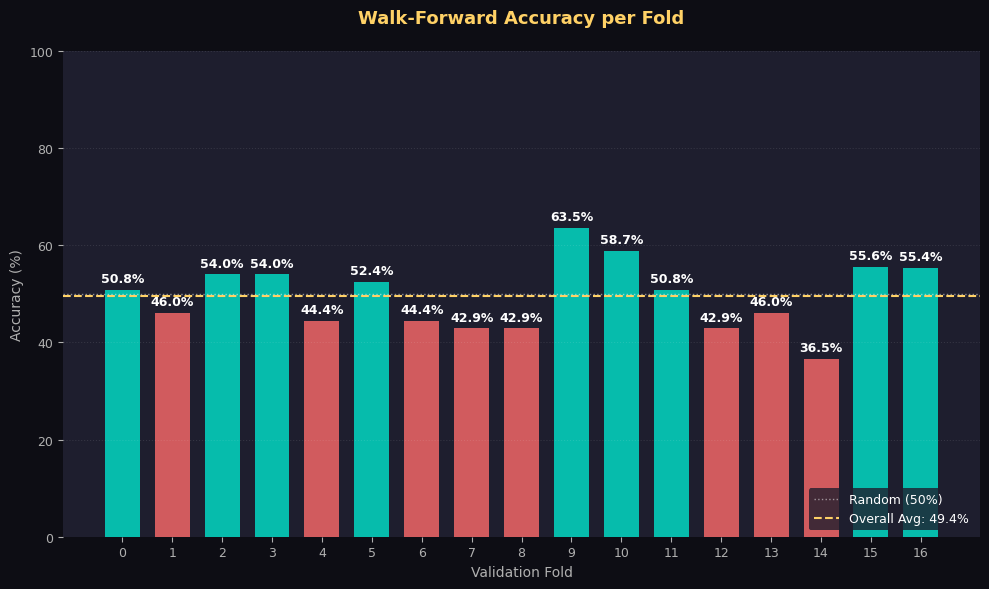

In [87]:
fig = plt.figure(figsize=(10, 6), facecolor=FIG_COLOR)
ax4 = fig.add_subplot(111)
ax4.set_facecolor(GRID_COLOR)

wf_accs = [f["Acc%"] for f in wf_metrics]
x_folds = range(len(wf_accs))
colors_bar = [ACCENT1 if a > 50 else ACCENT2 for a in wf_accs]

bars = ax4.bar(x_folds, wf_accs, color=colors_bar, alpha=0.8, width=0.7)

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{height:.1f}%", ha="center", va="bottom", 
             color="white", fontsize=9, fontweight="bold")

ax4.axhline(50, color="white", lw=1.0, linestyle=":", alpha=0.5, label="Random (50%)")
ax4.axhline(wf_acc, color=ACCENT3, lw=1.5, linestyle="--", label=f"Overall Avg: {wf_acc:.1f}%")

ax4.set_title("Walk-Forward Accuracy per Fold", color=ACCENT3, fontsize=13, fontweight="bold", pad=20)
ax4.set_xlabel("Validation Fold", color="#b0b0b0", fontsize=10)
ax4.set_ylabel("Accuracy (%)", color="#b0b0b0", fontsize=10)

ax4.legend(fontsize=9, facecolor=GRID_COLOR, labelcolor="white", edgecolor="none", loc="lower right")
ax4.tick_params(colors="#b0b0b0", labelsize=9)
ax4.set_xticks(x_folds)
ax4.set_ylim(0, 100)

for spine in ax4.spines.values():
    spine.set_visible(False)

ax4.yaxis.grid(True, linestyle=":", alpha=0.1, color="white")

plt.tight_layout()
plt.show()

#### P5: Confusion Matrix

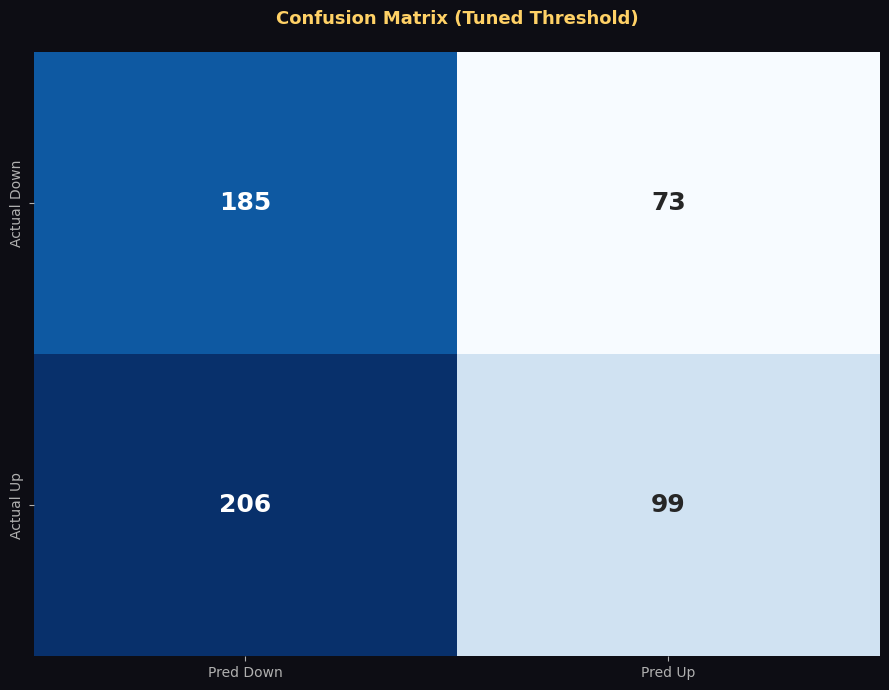

In [88]:
fig = plt.figure(figsize=(9, 7), facecolor=FIG_COLOR)
ax5 = fig.add_subplot(111)
ax5.set_facecolor(GRID_COLOR)

cm = confusion_matrix(y_bin_test, pred_test_tuned)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, 
            annot_kws={"size": 18, "fontweight": "bold"},
            xticklabels=["Pred Down", "Pred Up"], 
            yticklabels=["Actual Down", "Actual Up"], ax=ax5)

ax5.set_title("Confusion Matrix (Tuned Threshold)", color=ACCENT3, fontsize=13, fontweight="bold", pad=20)

ax5.tick_params(axis='x', colors="#b0b0b0", labelsize=10)
ax5.tick_params(axis='y', colors="#b0b0b0", labelsize=10)

plt.tight_layout()
plt.show()

# FINAL SUMMARY

In [89]:
print(f"""
  STEP 1 — FEATURE SELECTION
    {X_train.shape[1]} → {X_tr.shape[1]} features (Bypassed, Using All)

  STEP 3 — OPTUNA TUNING
    LightGBM CV AUC : {-study_lgb.best_value:.4f}
    XGBoost  CV AUC : {-study_xgb.best_value:.4f}

  STEP 5 — THRESHOLD TUNING (Raw Probabilities)
    Optimal θ       : {best_thresh:.2f}
    Test Acc        : {acc_test_tuned:.1f}%

  STEP 6 — WALK-FORWARD
    Overall Acc     : {wf_acc:.1f}%
    Overall AUC     : {wf_auc:.4f}

  STEP 7 — SIGNAL FUSION (Percentile-Based)
    θ_high / θ_low  : {THETA_H:.4f} / {THETA_L:.4f}  (Top {100-BEST_Q}% / Bottom {100-BEST_Q}%)
    Test active acc : {active_acc_test:.1f}%
    Test coverage   : {(mask_active_test.mean()*100):.1f}%
""")

output_df.to_csv(BASE + "classification_signals_v2_full.csv")
print(" Saved → classification_signals_v2_full.csv")


  STEP 1 — FEATURE SELECTION
    69 → 69 features (Bypassed, Using All)

  STEP 3 — OPTUNA TUNING
    LightGBM CV AUC : 0.5465
    XGBoost  CV AUC : 0.5308

  STEP 5 — THRESHOLD TUNING (Raw Probabilities)
    Optimal θ       : 0.51
    Test Acc        : 50.4%

  STEP 6 — WALK-FORWARD
    Overall Acc     : 49.4%
    Overall AUC     : 0.4937

  STEP 7 — SIGNAL FUSION (Percentile-Based)
    θ_high / θ_low  : 0.5204 / 0.4803  (Top 15.0% / Bottom 15.0%)
    Test active acc : 53.6%
    Test coverage   : 24.9%

 Saved → classification_signals_v2_full.csv


In [90]:
print(study_lgb.best_params)

{'n_estimators': 779, 'learning_rate': 0.023156834553476297, 'num_leaves': 55, 'max_depth': 5, 'min_child_samples': 23, 'subsample': 0.9994102717206793, 'colsample_bytree': 0.48279373698939754, 'reg_alpha': 0.07867938416831548, 'reg_lambda': 0.5694311944867698}
